In [2]:
# %pip install pandas
# %pip install yfinance

%pip install zoneinfo


Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement zoneinfo (from versions: none)
ERROR: No matching distribution found for zoneinfo
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Set-up and import

In [3]:

import sys
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
from black_scholes import black_scholes_price
from data_loader import (get_expiries, build_options_dataframe, get_underlying_history,
    compute_log_returns,
    compute_rolling_hist_vol)


This is where we can change the ticker and eventually adjust the risk free rate

In [4]:
ticker = "SPY"
expiry = get_expiries(ticker)[0]
r = 0.04

Pull data

In [5]:
options_df = build_options_dataframe(ticker, expiry)
options_df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,mid,option_type,S,expiry,T
0,SPY260312C00500000,2026-03-11 19:54:07+00:00,500.0,176.15,174.72,177.48,-5.170013,-2.851320,4.0,3.0,3.100588,True,REGULAR,USD,176.100,call,676.330017,2026-03-12,0.001993
1,SPY260312C00535000,2026-03-06 15:09:21+00:00,535.0,136.26,139.73,142.49,0.000000,0.000000,2.0,1.0,2.505375,True,REGULAR,USD,141.110,call,676.330017,2026-03-12,0.001993
2,SPY260312C00580000,2026-03-11 19:10:38+00:00,580.0,95.01,94.73,97.50,2.320000,2.502966,2.0,1.0,1.769044,True,REGULAR,USD,96.115,call,676.330017,2026-03-12,0.001993
3,SPY260312C00590000,2026-03-06 15:08:58+00:00,590.0,82.38,84.74,87.50,0.000000,0.000000,2.0,1.0,1.607424,True,REGULAR,USD,86.120,call,676.330017,2026-03-12,0.001993
4,SPY260312C00595000,2026-03-09 14:25:27+00:00,595.0,70.66,85.45,88.26,0.000000,0.000000,NaN,NaN,2.287846,True,REGULAR,USD,86.855,call,676.330017,2026-03-12,0.001993


Add to black scholes

In [6]:
options_df["K"] = options_df["strike"]
options_df["sigma"] = options_df["impliedVolatility"]
options_df["r"] = r

options_df = options_df[
    (options_df["K"] > 0) &
    (options_df["T"] > 0) &
    (options_df["sigma"] > 0) &
    (options_df["mid"] > 0)
].copy()


options_df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,contractSize,currency,mid,option_type,S,expiry,T,K,sigma,r
0,SPY260312C00500000,2026-03-11 19:54:07+00:00,500.0,176.15,174.72,177.48,-5.170013,-2.851320,4.0,3.0,...,REGULAR,USD,176.100,call,676.330017,2026-03-12,0.001993,500.0,3.100588,0.04
1,SPY260312C00535000,2026-03-06 15:09:21+00:00,535.0,136.26,139.73,142.49,0.000000,0.000000,2.0,1.0,...,REGULAR,USD,141.110,call,676.330017,2026-03-12,0.001993,535.0,2.505375,0.04
2,SPY260312C00580000,2026-03-11 19:10:38+00:00,580.0,95.01,94.73,97.50,2.320000,2.502966,2.0,1.0,...,REGULAR,USD,96.115,call,676.330017,2026-03-12,0.001993,580.0,1.769044,0.04
3,SPY260312C00590000,2026-03-06 15:08:58+00:00,590.0,82.38,84.74,87.50,0.000000,0.000000,2.0,1.0,...,REGULAR,USD,86.120,call,676.330017,2026-03-12,0.001993,590.0,1.607424,0.04
4,SPY260312C00595000,2026-03-09 14:25:27+00:00,595.0,70.66,85.45,88.26,0.000000,0.000000,NaN,NaN,...,REGULAR,USD,86.855,call,676.330017,2026-03-12,0.001993,595.0,2.287846,0.04


In [7]:
print(black_scholes_price)
print(type(black_scholes_price))
print("options_df shape:", options_df.shape)

if len(options_df) == 0:
    print("options_df is empty")
else:
    test_row = options_df.iloc[0]

    test_result = black_scholes_price(
        S=test_row["S"],
        K=test_row["K"],
        T=test_row["T"],
        r=test_row["r"],
        sigma=test_row["impliedVolatility"],
        option_type=test_row["option_type"]
    )

    print("RESULT:", test_result)
    print("TYPE:", type(test_result))

<function black_scholes_price at 0x1103feb80>
<class 'function'>
options_df shape: (196, 22)
RESULT: 168.14316940799307
TYPE: <class 'numpy.float64'>


Run BS pricing model 

In [8]:
options_df["bs_price_imp_vol"] = options_df.apply(
    lambda row: black_scholes_price(
        S=row["S"],
        K=row["K"],
        T=row["T"],
        r=row["r"],
        sigma=row["impliedVolatility"],
        option_type=row["option_type"]
    ),
    axis=1
)

options_df["mispricing_imp_vol"] = options_df["mid"] - options_df["bs_price_imp_vol"]
options_df["abs_error_imp_vol"] = options_df["mispricing_imp_vol"].abs()

Quick peek at output 

In [11]:
view_cols = [
    "contractSymbol", "option_type", "K", "mid", "bs_price_imp_vol",
    "mispricing_imp_vol", "abs_error_imp_vol", "sigma", "volume", "openInterest"
]

options_df.sort_values("abs_error_imp_vol", ascending=False)[view_cols].head(20)

,contractSymbol,option_type,K,mid,bs_price_imp_vol,mispricing_imp_vol,abs_error_imp_vol,sigma,volume,openInterest
160,SPY260312P00674000,put,674.0,2.280,-238.801561,241.081561,241.081561,0.236580,45086.0,1744.0
41,SPY260312C00674000,call,674.0,4.385,-231.739943,236.124943,236.124943,0.224861,22425.0,1333.0
161,SPY260312P00675000,put,675.0,2.640,-225.384426,228.024426,228.024426,0.232674,67676.0,4793.0
42,SPY260312C00675000,call,675.0,3.740,-218.372973,222.112973,222.112973,0.216805,53852.0,2298.0
165,SPY260312P00679000,put,679.0,4.565,222.701713,-218.136713,218.136713,0.222420,5557.0,1223.0
159,SPY260312P00673000,put,673.0,1.955,-214.103636,216.058636,216.058636,0.239754,24696.0,755.0
40,SPY260312C00673000,call,673.0,5.060,-205.035326,210.095326,210.095326,0.228157,8544.0,771.0
46,SPY260312C00679000,call,679.0,1.665,209.598264,-207.933264,207.933264,0.198983,31134.0,1184.0
166,SPY260312P00680000,put,680.0,5.115,197.402964,-192.287964,192.287964,0.213021,5336.0,5262.0
158,SPY260312P00672000,put,672.0,1.675,-184.666503,186.341503,186.341503,0.243538,36902.0,1306.0


Plotting (what does this mean, what am I looking at, what does this tell me? Who knows... hopefully the PhD research quants)

In [12]:
calls = options_df[options_df["option_type"] == "call"]
puts = options_df[options_df["option_type"] == "put"]

plt.figure(figsize=(10,6))

plt.scatter(calls["K"], calls["mispricing"], label="Calls")
plt.scatter(puts["K"], puts["mispricing"], label="Puts")

plt.axhline(0)
plt.xlabel("Strike")
plt.ylabel("Market - BS")
plt.legend()
plt.title("Mispricing by option type")
plt.show()

KeyError: 'mispricing'

<Figure size 1000x600 with 0 Axes>

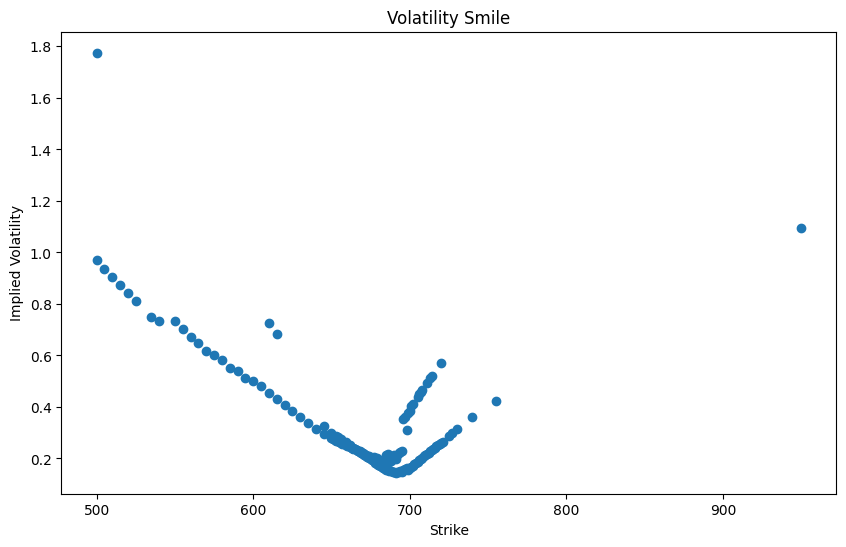

In [ ]:
#implied vol vs strike 
plt.figure(figsize=(10,6))

plt.scatter(options_df["K"], options_df["sigma"])

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.show()


In [13]:
hist = get_underlying_history(ticker, period="1y")
hist.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-03-12 00:00:00-04:00,555.644986,556.574078,547.263431,552.383301,69588200,0.0,0.0,0.0
2025-03-13 00:00:00-04:00,552.007661,552.620460,543.299920,545.019714,74079400,0.0,0.0,0.0
2025-03-14 00:00:00-04:00,549.655281,557.285707,545.088910,556.277527,62660300,0.0,0.0,0.0
2025-03-17 00:00:00-04:00,556.257760,563.097484,555.822864,560.567200,49008700,0.0,0.0,0.0
2025-03-18 00:00:00-04:00,558.244457,558.461935,552.571089,554.508362,66041400,0.0,0.0,0.0


In [14]:
hist[["Close"]].tail()


,Close
Date,
2026-03-05 00:00:00-05:00,681.309998
2026-03-06 00:00:00-05:00,672.380005
2026-03-09 00:00:00-04:00,678.270020
2026-03-10 00:00:00-04:00,677.179993
2026-03-11 00:00:00-04:00,676.330017


In [15]:
## Computing log returns of close 
hist["log_return"] = compute_log_returns(hist["Close"])
hist[["Close", "log_return"]].tail(10)

,Close,log_return
Date,,
2026-02-26 00:00:00-05:00,689.299988,-0.005570
2026-02-27 00:00:00-05:00,685.989990,-0.004814
2026-03-02 00:00:00-05:00,686.380005,0.000568
2026-03-03 00:00:00-05:00,680.330017,-0.008853
2026-03-04 00:00:00-05:00,685.130005,0.007031
2026-03-05 00:00:00-05:00,681.309998,-0.005591
2026-03-06 00:00:00-05:00,672.380005,-0.013194
2026-03-09 00:00:00-04:00,678.270020,0.008722
2026-03-10 00:00:00-04:00,677.179993,-0.001608


In [16]:
## Compute 30 day rolling historical volatility
hist["hist_vol_30d"] = compute_rolling_hist_vol(hist["Close"], window=30)
hist[["Close", "log_return", "hist_vol_30d"]].tail(15)

,Close,log_return,hist_vol_30d
Date,,,
2026-02-19 00:00:00-05:00,684.479980,-0.002641,0.120554
2026-02-20 00:00:00-05:00,689.429993,0.007206,0.122175
2026-02-23 00:00:00-05:00,682.390015,-0.010264,0.125741
2026-02-24 00:00:00-05:00,687.349976,0.007242,0.126067
2026-02-25 00:00:00-05:00,693.150024,0.008403,0.128491
2026-02-26 00:00:00-05:00,689.299988,-0.005570,0.129364
2026-02-27 00:00:00-05:00,685.989990,-0.004814,0.129328
2026-03-02 00:00:00-05:00,686.380005,0.000568,0.129055
2026-03-03 00:00:00-05:00,680.330017,-0.008853,0.131423


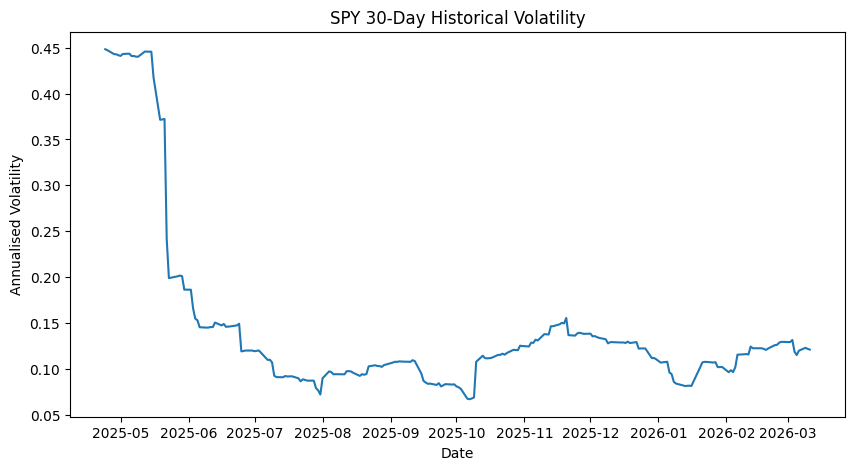

In [17]:
## Visualise last 6 months

plt.figure(figsize=(10, 5))
plt.plot(hist.index, hist["hist_vol_30d"])
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.title(f"{ticker} 30-Day Historical Volatility")
plt.show()

In [18]:
## Compute single BS sigma implied vol for a given option
latest_hist_vol = hist["hist_vol_30d"].dropna().iloc[-1]
print("Latest 30D historical volatility:", latest_hist_vol)

Latest 30D historical volatility: 0.12090833833291037


In [19]:
##Adding historical volatility to our options dataframe 
options_df["sigma_hist"] = latest_hist_vol

In [ ]:
options_df["bs_price_hist"] = options_df.apply(
    lambda row: black_scholes_price(
        S=row["S"],
        K=row["K"],
        T=row["T"],
        r=row["r"],
        sigma=row["sigma_hist"],
        option_type=row["option_type"]
    ),
    axis=1
)

In [ ]:
##These numbers are sus no? 

options_df[["bs_price_hist"]].head()

,bs_price_hist
0,176.369882
1,141.372672
2,96.376260
3,86.377057
4,81.377456


In [29]:
options_df["mispricing_imp_vol"] = options_df["mid"] - options_df["bs_price_imp_vol"]
options_df["abs_error_imp_vol"] = options_df["mispricing_imp_vol"].abs()

options_df["mispricing_hist"] = options_df["mid"] - options_df["bs_price_hist"]
options_df["abs_error_hist"] = options_df["mispricing_hist"].abs()

print("Mean abs error using implied vol:   ", options_df["abs_error_imp_vol"].mean())
print("Mean abs error using historical vol:", options_df["abs_error_hist"].mean())

Mean abs error using implied vol:    41.073887446539565
Mean abs error using historical vol: 13.993034472237566


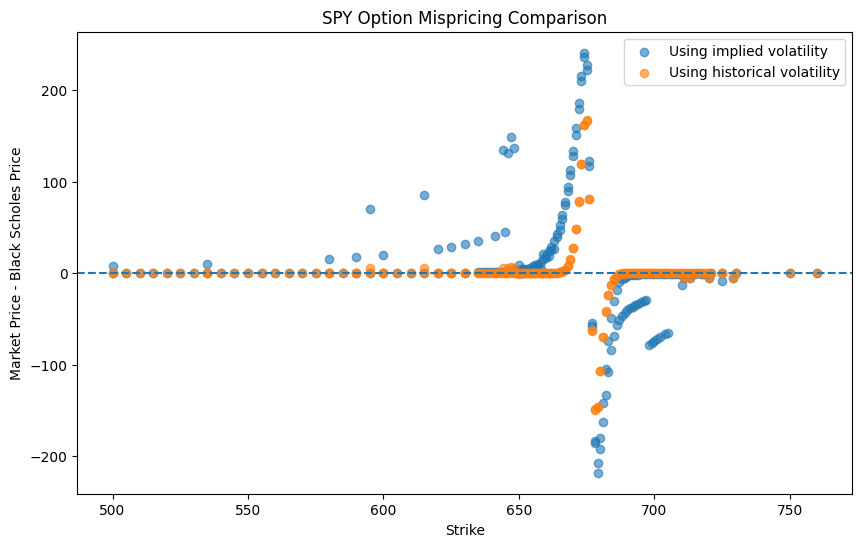

In [ ]:
##Option mispricing comparison plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    options_df["K"],
    options_df["mispricing_imp_vol"],
    alpha=0.6,
    label="Using implied volatility"
)

plt.scatter(
    options_df["K"],
    options_df["mispricing_hist"],
    alpha=0.6,
    label="Using historical volatility"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Strike")
plt.ylabel("Market Price - Black Scholes Price")
plt.title(f"{ticker} Option Mispricing Comparison")
plt.legend()

plt.show()

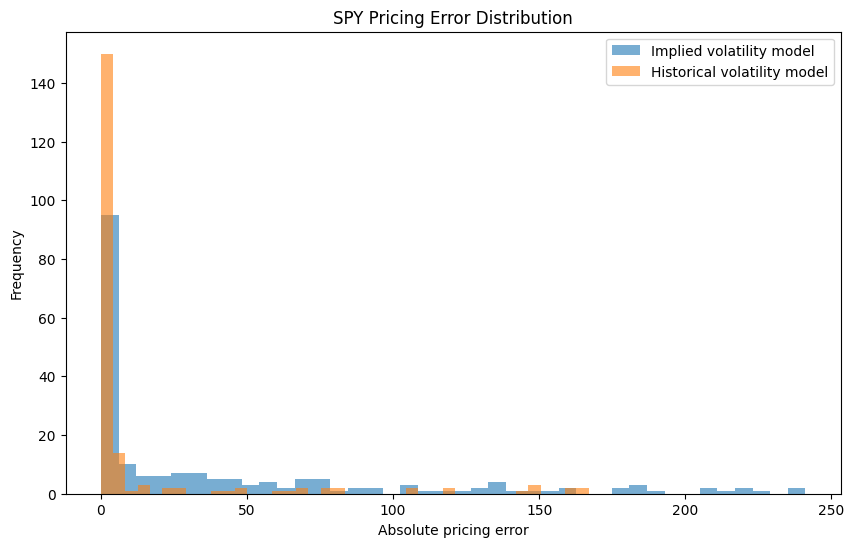

In [31]:
##Error distribution plot 
plt.figure(figsize=(10,6))

plt.hist(
    options_df["abs_error_imp_vol"],
    bins=40,
    alpha=0.6,
    label="Implied volatility model"
)

plt.hist(
    options_df["abs_error_hist"],
    bins=40,
    alpha=0.6,
    label="Historical volatility model"
)

plt.xlabel("Absolute pricing error")
plt.ylabel("Frequency")
plt.title(f"{ticker} Pricing Error Distribution")
plt.legend()

plt.show()

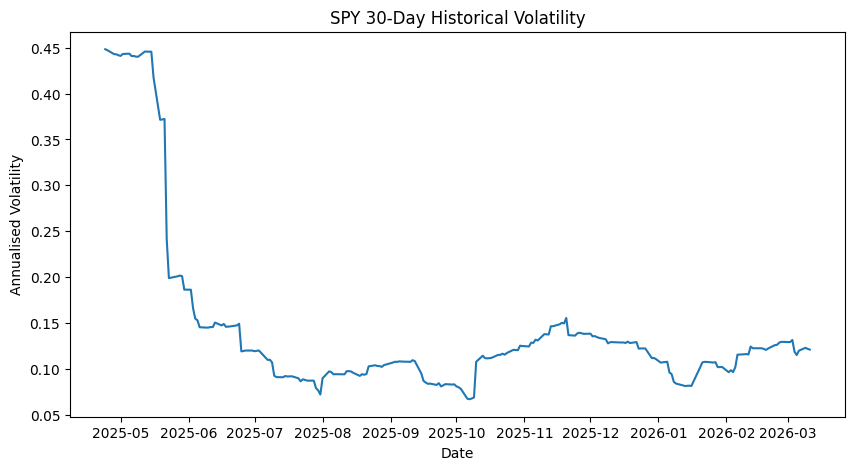